
# SNP-BINN Analysis Pipeline
# 
# A complete 10-step pipeline for analyzing SNP data using Biologically Informed Neural Networks (BINN).
# 
# **Pipeline Overview:**
# 1. SNP genotype data → Gene-level signals → Pathway analysis → Disease prediction
# 2. Uses Reactome biological pathways to constrain neural network architecture
# 3. SHAP interpretation for biological insights




## Setup and Installation

# 
# Install required packages (uncomment if needed)
# !pip install binn torch pandas numpy scipy scikit-learn matplotlib seaborn networkx shap

In [6]:
# Import libraries
import numpy as np
import pandas as pd
import json
from scipy import sparse
from binn import BINN, BINNDataLoader, BINNTrainer, BINNExplainer
import warnings
warnings.filterwarnings('ignore')

print("Setup complete!")


Setup complete!


# Step 1: Load Genotype Data

In [7]:
def load_genotype_data(file_path='dummy_genotype_matrix.npz'):
    """
    Load SNP genotype matrix and metadata.
    
    Returns:
        genotype_matrix: (n_patients, n_snps) array
        snps: list of SNP identifiers  
        samples: list of sample identifiers
    """
    print("Step 1: Loading genotype data...")
    loaded = np.load(file_path, allow_pickle=True)
    genotype_matrix = loaded['matrix']
    snps = loaded['snps']
    samples = loaded['samples']
    print(f"Loaded genotype matrix: {genotype_matrix.shape}")
    return genotype_matrix, snps, samples

# Execute step 1

In [8]:
genotype_matrix, snps, samples = load_genotype_data()

Step 1: Loading genotype data...
Loaded genotype matrix: (50, 100)


# Step 2: Load SNP-Gene Mapping

In [9]:
def load_snp_gene_mapping(file_path='sparse_matrix.npz'):
    """
    Load sparse matrix defining which SNPs affect which genes.
    
    Returns:
        snp_to_gene: (n_snps, n_genes) sparse matrix
    """
    print("Step 2: Loading SNP-to-gene mapping...")
    sparse_loaded = np.load(file_path, allow_pickle=True)
    
    if 'data' in sparse_loaded.keys():
        snp_to_gene = sparse.csr_matrix(
            (sparse_loaded['data'], sparse_loaded['indices'], sparse_loaded['indptr']),
            shape=tuple(sparse_loaded['shape'])
        )
    else:
        snp_to_gene = sparse_loaded['matrix']
    
    print(f"Loaded SNP-gene matrix: {snp_to_gene.shape}")
    return snp_to_gene

In [10]:
snp_to_gene = load_snp_gene_mapping()

Step 2: Loading SNP-to-gene mapping...
Loaded SNP-gene matrix: (100, 122)


# Step 3: Load Gene Index

In [11]:
def load_gene_index(file_path='gene_index.json'):
    """
    Load gene names from index file.
    
    Returns:
        gene_names: list of gene identifiers
    """
    print("Step 3: Loading gene index...")
    with open(file_path, 'r') as f:
        gene_index = json.load(f)
    gene_names = list(gene_index.keys())
    print(f"Loaded {len(gene_names)} genes")
    return gene_names

# Execute step 3

In [12]:
gene_names = load_gene_index()

Step 3: Loading gene index...
Loaded 122 genes


# Step 4: Transform SNPs to Genes

In [13]:
def transform_snps_to_genes(genotype_matrix, snp_to_gene):
    """
    Convert SNP data to gene-level signals via matrix multiplication.
    
    Args:
        genotype_matrix: (n_patients, n_snps)
        snp_to_gene: (n_snps, n_genes) sparse matrix
    
    Returns:
        gene_signals: (n_patients, n_genes) array
    """
    print("Step 4: Transforming SNPs to gene signals...")
    if sparse.issparse(snp_to_gene):
        snp_to_gene = snp_to_gene.toarray()
    
    gene_signals = genotype_matrix @ snp_to_gene
    print(f"Gene signals shape: {gene_signals.shape}")
    return gene_signals

# Execute step 4

In [14]:
gene_signals = transform_snps_to_genes(genotype_matrix, snp_to_gene)

Step 4: Transforming SNPs to gene signals...
Gene signals shape: (50, 122)


# Step 5: Create Gene-Pathway Mapping

In [15]:
def create_gene_pathway_mapping(gmt_file='ReactomePathways.gmt'):
    """
    Parse Reactome GMT file to map genes to pathways.
    
    Returns:
        mapping_df: DataFrame with 'input' (gene) and 'translation' (pathway) columns
    """
    print("Step 5: Creating gene-pathway mapping...")
    gene_to_pathway = []
    
    with open(gmt_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                reactome_id = parts[1]  # Use Reactome ID
                genes = parts[2:]
                
                for gene in genes:
                    gene_to_pathway.append({
                        'input': gene,
                        'translation': reactome_id
                    })
    
    mapping_df = pd.DataFrame(gene_to_pathway)
    print(f"Created {len(mapping_df)} gene-pathway mappings")
    return mapping_df

# Execute step 5

In [16]:
mapping_df = create_gene_pathway_mapping()

Step 5: Creating gene-pathway mapping...
Created 135371 gene-pathway mappings


# Step 6: Load Pathway Hierarchy

In [19]:
def load_pathway_hierarchy(file_path='reactome_pathways_relation_2025_01_14.txt'):
    """
    Load pathway hierarchy without manual output_node addition.
    BINN will handle output_node automatically.
    
    Returns:
        pathways_df: DataFrame with 'source' and 'target' columns
    """
    print("Step 6: Loading pathway hierarchy...")
    pathways_df = pd.read_csv(file_path, sep='\t', header=None)
    pathways_df.columns = ['source', 'target']
    print(f"Loaded {len(pathways_df)} pathway connections")
    return pathways_df

# Execute step 6

In [20]:
pathways_df = load_pathway_hierarchy()

Step 6: Loading pathway hierarchy...
Loaded 22746 pathway connections


# Step 7: Prepare Training Data

In [22]:
def prepare_training_data(gene_signals, gene_names):
    """
    Format data for BINN input and create sample labels.
    
    Returns:
        gene_data: DataFrame formatted for BINN
        design_matrix: DataFrame with sample labels
    """
    print("Step 7: Preparing training data...")
    
    # Create sample names
    sample_names = [f"Patient_{i}" for i in range(gene_signals.shape[0])]
    
    # Format for BINN (genes as rows)
    gene_data = pd.DataFrame(
        gene_signals.T,
        index=gene_names,
        columns=sample_names
    ).reset_index().rename(columns={'index': 'Protein'})
    
    # Create random labels for demo
    n_samples = len(sample_names)
    n_case = n_samples // 2
    labels = ['case'] * n_case + ['control'] * (n_samples - n_case)
    np.random.shuffle(labels)
    
    design_matrix = pd.DataFrame({
        'sample': sample_names,
        'group': labels
    })
    
    print(f"Training data shape: {gene_data.shape}")
    print(f"Labels: {pd.Series(labels).value_counts().to_dict()}")
    return gene_data, design_matrix

# Execute step 7

In [23]:
gene_data, design_matrix = prepare_training_data(gene_signals, gene_names)


Step 7: Preparing training data...
Training data shape: (122, 51)
Labels: {'case': 25, 'control': 25}


# Step 8: Create BINN Model

In [25]:
def create_binn_model(gene_data, mapping_df, pathways_df):
    """
    Create BINN model using original approach (automatic output_node).
    
    Returns:
        binn: Configured BINN model
    """
    print("Step 8: Creating BINN model...")
    
    binn = BINN(
        data_matrix=gene_data,
        mapping=mapping_df,
        pathways=pathways_df,
        entity_col='Protein',
        input_col='input',
        translation_col='translation',
        source_col='source',
        target_col='target',
        n_layers=4,
        n_outputs=2,
        dropout=0.2,
        device='cpu'
    )
    
    print(f"Created BINN with {len(binn.connectivity_matrices)} layers")
    print(f"Input features: {len(binn.inputs)}")
    return binn

# Execute step 8

In [26]:
binn = create_binn_model(gene_data, mapping_df, pathways_df)


Step 8: Creating BINN model...

[INFO] BINN is on device: cpu
Created BINN with 5 layers
Input features: 51


# Step 9: Train Model

In [27]:
def train_binn_model(binn, gene_data, design_matrix, epochs=10):
    """
    Train BINN model for disease classification.
    
    Returns:
        trainer: Trained model trainer
        dataloaders: Data loaders used for training
    """
    print("Step 9: Training BINN model...")
    
    # Create data loaders
    dataloader = BINNDataLoader(binn)
    dataloaders = dataloader.create_dataloaders(
        data_matrix=gene_data,
        design_matrix=design_matrix,
        feature_column="Protein",
        group_column="group",
        sample_column="sample",
        batch_size=8,
        validation_split=0.2
    )
    
    # Train model
    trainer = BINNTrainer(binn)
    trainer.fit(dataloaders=dataloaders, num_epochs=epochs)
    
    print("Training completed")
    return trainer, dataloaders

# Execute step 9

In [30]:
trainer, dataloaders = train_binn_model(binn, gene_data, design_matrix, epochs=10)

Step 9: Training BINN model...
Mapping group labels: {'case': 0, 'control': 1}
[Epoch 1/10] Train Loss: 0.6615, Train Accuracy: 0.5750
[Epoch 1/10] Val Loss: 0.7998, Val Accuracy: 0.2500
[Epoch 2/10] Train Loss: 0.6607, Train Accuracy: 0.6000
[Epoch 2/10] Val Loss: 0.8018, Val Accuracy: 0.2500
[Epoch 3/10] Train Loss: 0.5352, Train Accuracy: 0.7250
[Epoch 3/10] Val Loss: 0.8986, Val Accuracy: 0.5000
[Epoch 4/10] Train Loss: 0.6670, Train Accuracy: 0.5750
[Epoch 4/10] Val Loss: 1.0362, Val Accuracy: 0.5000
[Epoch 5/10] Train Loss: 0.5856, Train Accuracy: 0.7250
[Epoch 5/10] Val Loss: 0.8357, Val Accuracy: 0.5000
[Epoch 6/10] Train Loss: 0.6297, Train Accuracy: 0.6500
[Epoch 6/10] Val Loss: 0.8134, Val Accuracy: 0.2500
[Epoch 7/10] Train Loss: 0.6134, Train Accuracy: 0.6500
[Epoch 7/10] Val Loss: 0.8132, Val Accuracy: 0.1875
[Epoch 8/10] Train Loss: 0.5707, Train Accuracy: 0.7500
[Epoch 8/10] Val Loss: 0.8621, Val Accuracy: 0.5000
[Epoch 9/10] Train Loss: 0.5610, Train Accuracy: 0.7000
[

## Step 10: Interpret Results

In [31]:
def interpret_model(binn, dataloaders):
    """
    Use SHAP to interpret important pathways.
    
    Returns:
        explanations: DataFrame with pathway importance scores
    """
    print("Step 10: Interpreting model...")
    
    explainer = BINNExplainer(binn)
    explanations = explainer.explain_single(
        dataloaders,
        split="val",
        normalization_method="subgraph"
    )
    
    # Show top important features
    if len(explanations) > 0:
        top_features = (
            explanations
            .groupby('source_node')['importance']
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )
        print("Top 10 important features:")
        for feature, importance in top_features.items():
            print(f"  {feature}: {importance:.4f}")
    
    return explanations


# Execute step 10

In [32]:
explanations = interpret_model(binn, dataloaders)


Step 10: Interpreting model...
Top 10 important features:
  R-HSA-5619102: 8.3142
  GNAI3: 2.0487
  R-HSA-71291: 1.9293
  LAMC1: 1.9123
  R-HSA-1266738: 1.7836
  R-HSA-74160: 1.7553
  R-HSA-1643685: 1.6179
  CDC7: 1.5592
  R-HSA-162582: 1.5351
  R-HSA-1430728: 1.4305


## Results Summary

In [33]:
results = {
    'binn': binn,
    'trainer': trainer,
    'dataloaders': dataloaders,
    'explanations': explanations,
    'gene_data': gene_data,
    'design_matrix': design_matrix
}

# Validate and summarize results
print("SNP-BINN Pipeline Results:")
print("=" * 40)
print(f"Model input features: {len(results['binn'].inputs)}")
print(f"Network layers: {len(results['binn'].connectivity_matrices)}")
print(f"Total parameters: {sum(p.numel() for p in results['binn'].parameters()):,}")
print(f"Explanations generated: {len(results['explanations'])}")
print("\nPipeline Status: COMPLETED SUCCESSFULLY")

# Show layer connectivity
print("\nLayer Connectivity:")
for i, matrix in enumerate(results['binn'].connectivity_matrices):
    connections = matrix.sum().sum()
    density = connections / (matrix.shape[0] * matrix.shape[1]) * 100
    print(f"  Layer {i}: {matrix.shape[0]}→{matrix.shape[1]} ({connections:.0f} connections, {density:.1f}% density)")

SNP-BINN Pipeline Results:
Model input features: 51
Network layers: 5
Total parameters: 1,209,643
Explanations generated: 8050

Pipeline Status: COMPLETED SUCCESSFULLY

Layer Connectivity:
  Layer 0: 51→22 (106 connections, 9.4% density)
  Layer 1: 22→99 (41 connections, 1.9% density)
  Layer 2: 99→627 (242 connections, 0.4% density)
  Layer 3: 627→1807 (1829 connections, 0.2% density)
  Layer 4: 1807→1 (1807 connections, 100.0% density)


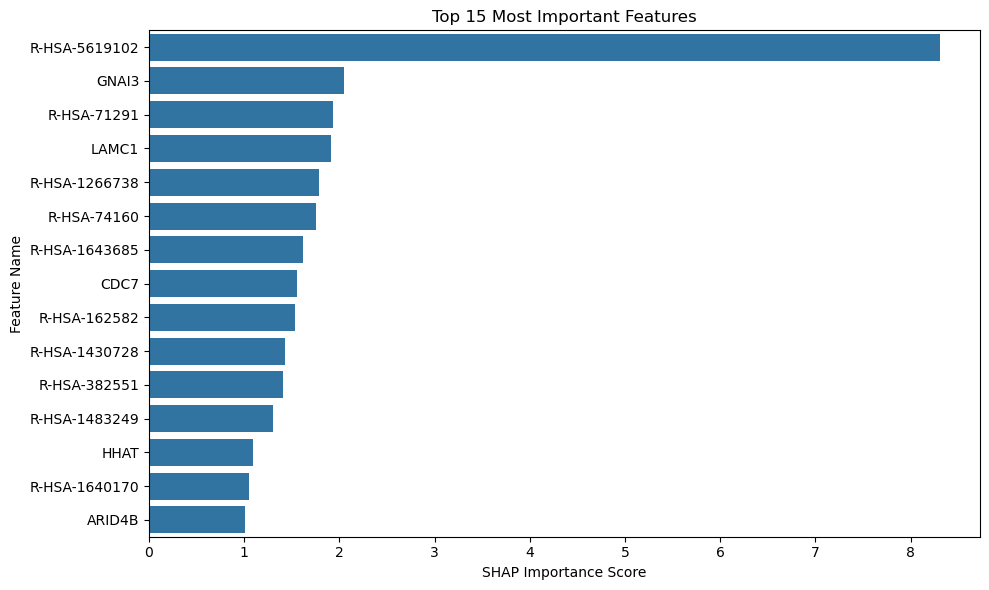

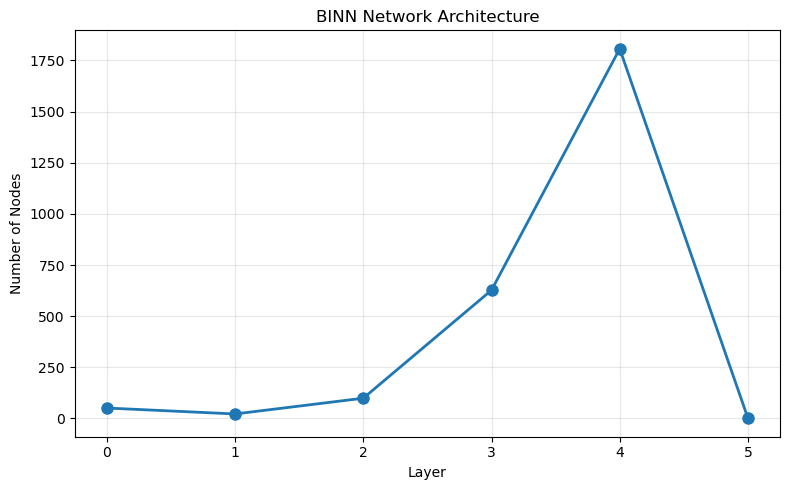

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top important features
if len(explanations) > 0:
    top_features = (
        explanations
        .groupby('source_node')['importance']
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_features.values, y=top_features.index)
    plt.title('Top 15 Most Important Features')
    plt.xlabel('SHAP Importance Score')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.show()

# Plot network layer sizes
layer_sizes = [matrix.shape[0] for matrix in results['binn'].connectivity_matrices]
layer_sizes.append(results['binn'].connectivity_matrices[-1].shape[1])

plt.figure(figsize=(8, 5))
plt.plot(range(len(layer_sizes)), layer_sizes, 'o-', linewidth=2, markersize=8)
plt.title('BINN Network Architecture')
plt.xlabel('Layer')
plt.ylabel('Number of Nodes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

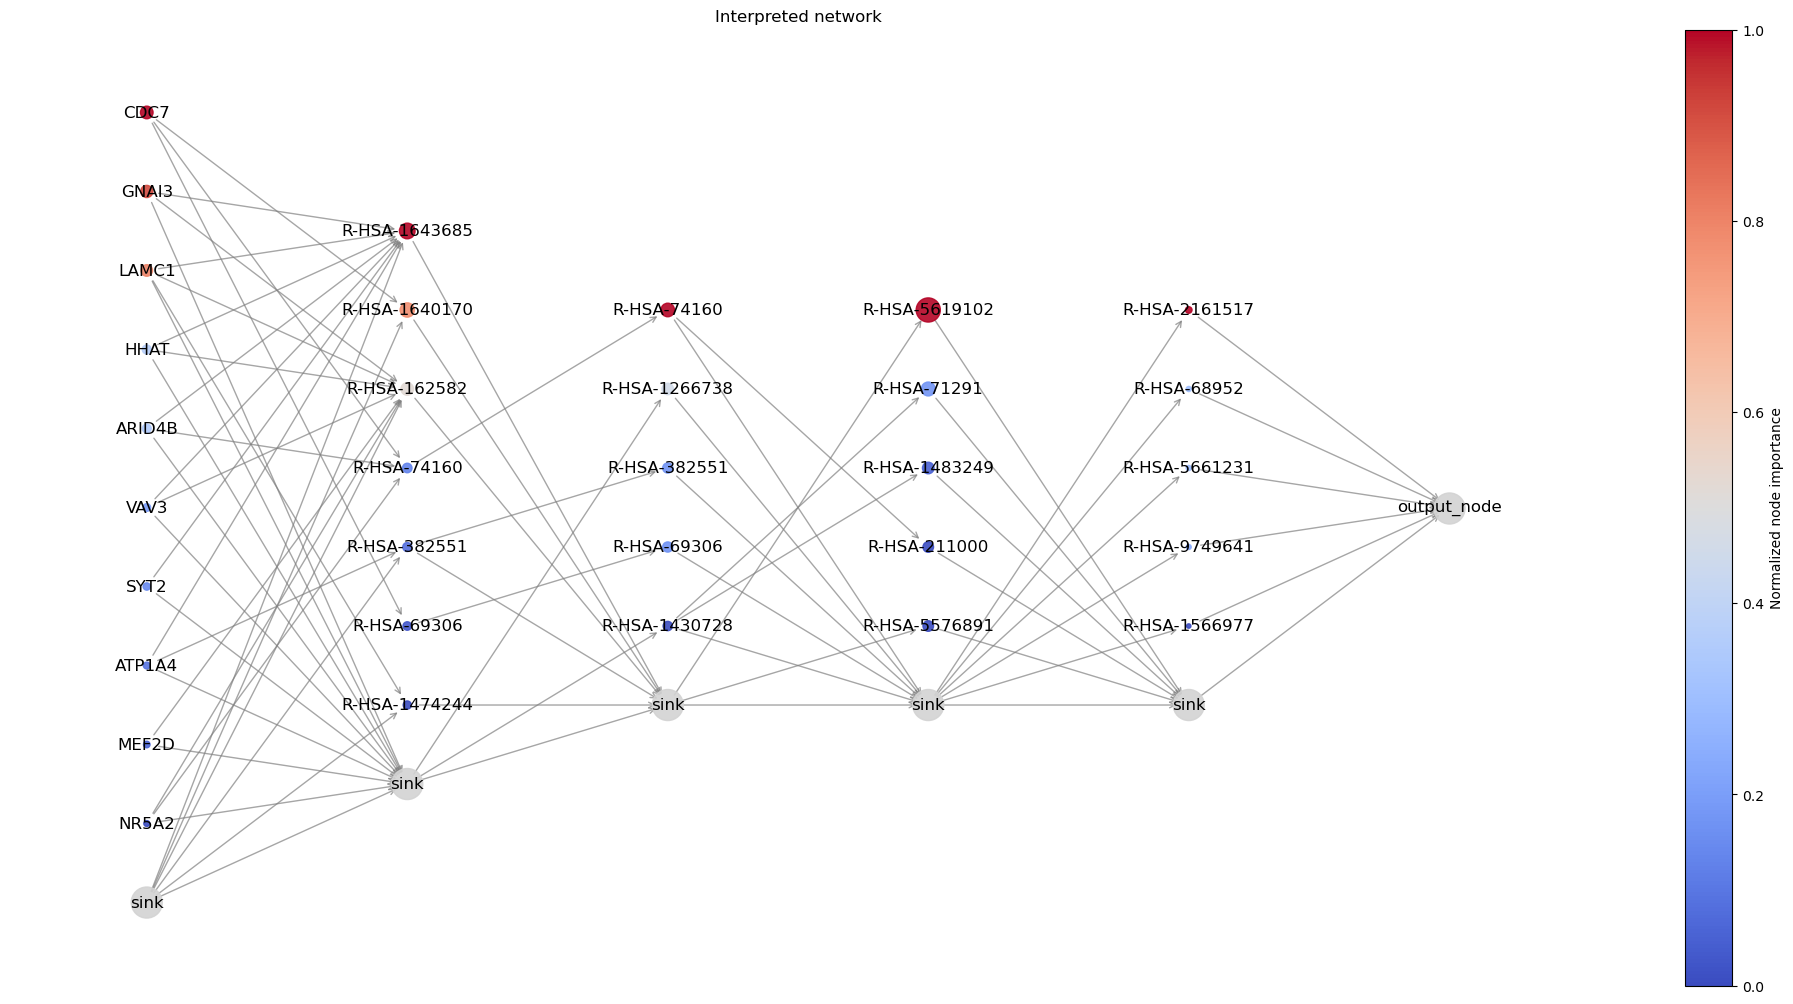

In [35]:
# @title ## 5. Plot
from binn.plot.network import visualize_binn

layer_specific_top_n = {"0": 10, "1": 7, "2": 5, "3": 5, "4": 5}

plt = visualize_binn(
    explanations,
    top_n=layer_specific_top_n,
    plot_size=(20, 10),
    sink_node_size=500,
    node_size_scaling=200,
    edge_width=1,
    node_cmap="coolwarm"
)

plt.title("Interpreted network")
plt.show()
     

In [39]:
for l in binn.layer_names:
    print(l)

['ABCD3', 'AGBL4', 'ARID4B', 'ATP1A4', 'CACNA1E', 'CDC7', 'CHRM3', 'CYB5R1', 'DENND2D', 'EDARADD', 'FLVCR1', 'FMOD', 'GNAI3', 'GREM2', 'HHAT', 'KAZN', 'KCNK2', 'KIF14', 'LAMC1', 'LCE3E', 'LPGAT1', 'MEF2D', 'MSH4', 'MTF1', 'NEGR1', 'NR5A2', 'NTNG1', 'OTUD7B', 'PADI6', 'PDE4B', 'PLOD1', 'PRELP', 'RHOU', 'RSPO1', 'RYR2', 'S100A7', 'S100A7A', 'SCP2', 'SELL', 'SELP', 'SH2D1B', 'SLC30A10', 'SMYD3', 'SPSB1', 'SYT2', 'TGFBR3', 'TNFSF4', 'UHMK1', 'USP24', 'VAV3', 'WNT2B']
['R-HSA-109582', 'R-HSA-112316', 'R-HSA-1266738', 'R-HSA-1430728', 'R-HSA-1474165', 'R-HSA-1474244', 'R-HSA-162582', 'R-HSA-1640170', 'R-HSA-1643685', 'R-HSA-168256', 'R-HSA-1852241', 'R-HSA-382551', 'R-HSA-392499', 'R-HSA-397014', 'R-HSA-4839726', 'R-HSA-5653656', 'R-HSA-69306', 'R-HSA-74160', 'R-HSA-8953897', 'R-HSA-9609507', 'R-HSA-9697154', 'R-HSA-9748784']
['R-HSA-109582', 'R-HSA-111997', 'R-HSA-112043', 'R-HSA-112311', 'R-HSA-112314', 'R-HSA-112316', 'R-HSA-1226099', 'R-HSA-1266738', 'R-HSA-1430728', 'R-HSA-1474165', 'R-